✅ Dataset loaded successfully!
Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.14

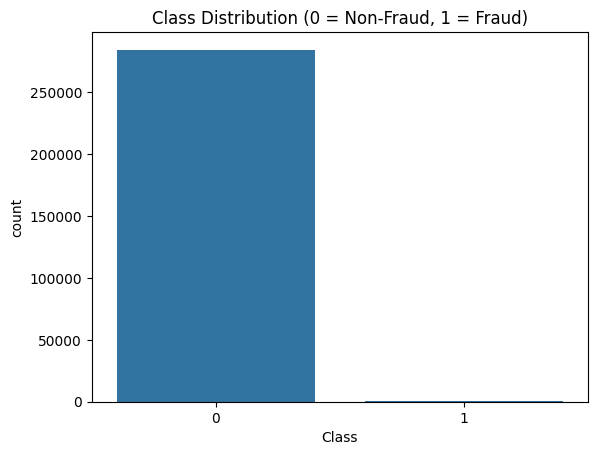


Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

✅ Data split complete!
Training samples: 199364
Testing samples: 85443

✅ Logistic Regression model trained!

🔹 Logistic Regression Results 🔹
Accuracy: 99.92 %

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.61      0.72       148

    accuracy                           1.00     85443
   macro avg       0.93      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



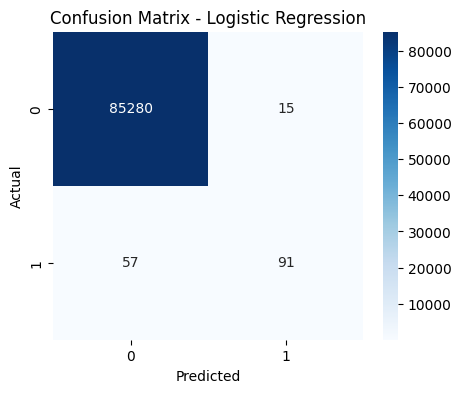

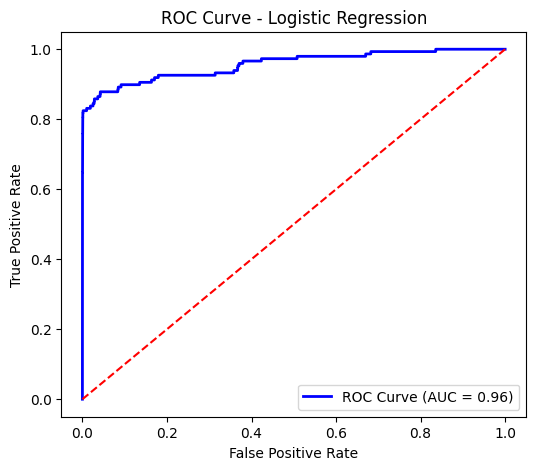


✅ Random Forest model trained!
Accuracy: 99.95 %


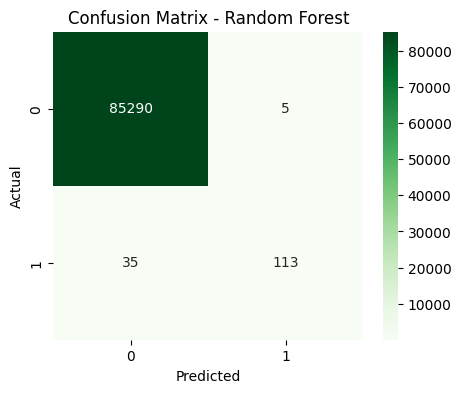


🔹 Sample Transaction Data:
               V1        V2        V3        V4        V5        V6        V7  \
109561 -0.885863  1.221585  0.758673  0.652787 -0.023365 -0.389479  0.399817   

              V8        V9       V10  ...       V20       V21       V22  \
109561  0.364382 -0.326113  0.499238  ...  0.129045  0.076149  0.383889   

             V23       V24       V25       V26       V27       V28  normAmount  
109561 -0.138805 -0.035674 -0.185248 -0.328806  0.227426 -0.023927   -0.296696  

[1 rows x 29 columns]

🔍 Prediction: ✅ NOT FRAUD

🏁 Project Summary:
- Dataset: (284807, 30) transactions
- Models Used: Logistic Regression, Random Forest
- ROC AUC (Logistic Regression): 0.956
- Note: Class imbalance handled through stratified split. Consider SMOTE for better recall.


In [ ]:
# ==============================================
# 💳 CREDIT CARD FRAUD DETECTION USING ML
# ==============================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

# Step 2: Load Dataset
url = "/content/creditcard.csv.zip"
data = pd.read_csv(url)
print("✅ Dataset loaded successfully!")
print("Shape:", data.shape)
print(data.head())

# Step 3: Data Exploration
sns.countplot(x='Class', data=data)
plt.title("Class Distribution (0 = Non-Fraud, 1 = Fraud)")
plt.show()
print("\nClass counts:\n", data['Class'].value_counts())

# Step 4: Data Preprocessing
scaler = StandardScaler()
data['normAmount'] = scaler.fit_transform(data['Amount'].values.reshape(-1,1))
data = data.drop(['Time','Amount'], axis=1)

X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("\n✅ Data split complete!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Step 5: Train Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("\n✅ Logistic Regression model trained!")

# Step 6: Evaluate Model
print("\n🔹 Logistic Regression Results 🔹")
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Step 7: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 8: ROC Curve
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'--',color='red')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# Step 9: Train Random Forest (for comparison)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("\n✅ Random Forest model trained!")
print("Accuracy:", round(accuracy_score(y_test, rf_pred)*100, 2), "%")

# Step 10: Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 11: Sample Prediction
sample = X_test.sample(1, random_state=42)
print("\n🔹 Sample Transaction Data:\n", sample)
pred = model.predict(sample)
print("\n🔍 Prediction:", "⚠️ FRAUD DETECTED" if pred[0]==1 else "✅ NOT FRAUD")

# Step 12: Summary
print("\n🏁 Project Summary:")
print("- Dataset:", data.shape, "transactions")
print("- Models Used: Logistic Regression, Random Forest")
print("- ROC AUC (Logistic Regression):", round(roc_auc, 3))
print("- Note: Class imbalance handled through stratified split. Consider SMOTE for better recall.")
